In [99]:
import os
import glob
import json
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from vip_slap2_analysis.utils.utils import save_figure
from vip_slap2_analysis.io.session_registry import VIPSessionRegistry

import seaborn as sns
sns.set_style('white')
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [29]:
%load_ext autoreload
%autoreload 2

In [28]:
%matplotlib notebook

In [100]:
savepath = r"C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-03-17_OPhys_LabMeetingIV\figures"

In [107]:
target_mice = [
#     803496,
#     804730,804733,810196,
#     809047,
#     803121,
#     826033,838410,
    834788
]

In [108]:
registry = VIPSessionRegistry.from_basepath(
    r'\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics'
)

process_df = registry.sessions(
    subject_ids=target_mice,
    exclude_session_types=["expression_check","volume_imaging"],
    paradigms=["change_detection_passive"],
)

assets = [registry.resolve_assets(row) for _, row in process_df.iterrows()]

In [109]:
test_asset = assets[3]

### Plot mean image response

In [110]:
mean_data_path = glob.glob(os.path.join(test_asset.derived_dir,'**','glutamate_mean_df.npz'))[0]
glu_qc_path = glob.glob(os.path.join(test_asset.qc_dir,'**','**glutamate**'))[0]

In [111]:
glu_mean = np.load(mean_data_path,allow_pickle=True)['data'][0]

In [112]:
with open(glu_qc_path, "r") as f:
    glu_qc = json.load(f)

In [113]:
im_names = list(glu_mean['DMD1']['image_identity'].keys())
colors = ['#c5cae9', '#ffcdd2', '#c8e6c9', '#ffe0b2',
 '#e1bee7', '#d7ccc8', '#cfd8dc', '#b2ebf2']

<IPython.core.display.Javascript object>


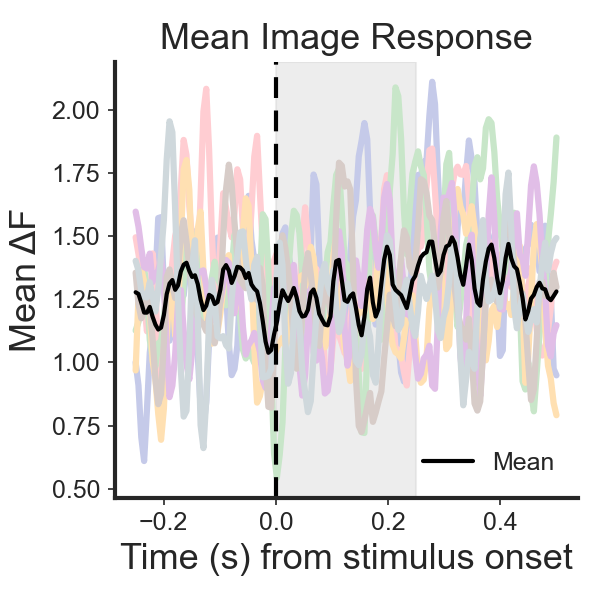

In [145]:
dmd = 1
syn = 11

fig,ax=plt.subplots(figsize=(4,4))

sns.despine()

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

for i,im in enumerate(im_names):

    glu_signal = glu_mean[f'DMD{dmd}']['image_identity'][im_names[i]]['mean'][syn]
    time = np.linspace(-0.25,0.5,len(glu_signal))
    ax.plot(time,pd.DataFrame(glu_signal).rolling(1,min_periods=1).mean(),lw=3,color=colors[i])

mean = np.mean([glu_mean[f'DMD{dmd}']['image_identity'][im_names[i]]['mean'][syn]for i,im in enumerate(im_names)],axis=0 )

# ax.fill_between(time[50:100],min(mean[50:100]),mean[50:100],color='lightgray',zorder=0,alpha=0.4,label='AUC')
# ax.fill_between(time[:50],min(mean[:50]),mean[:50],color='lightgray',zorder=0,alpha=0.4)

ax.plot(time,pd.DataFrame(mean).rolling(1,min_periods=1).mean(),color='k',lw=2,label='Mean')

ax.axvline(0.0,color='k',dashes=[5,3],lw=2)
ax.axvspan(0.0,0.25,color='lightgray',alpha=0.4,zorder=0)

ax.set_xlabel('Time (s) from stimulus onset')
ax.set_ylabel('Mean \u0394F')

for spine in ['left','bottom']:
    ax.spines[spine].set_linewidth(2)

ax.set_title('Mean Image Response')
ax.legend(frameon=False,fontsize=12)
fig.tight_layout()

filen = '2026-03-30_AUC1'
# save_figure(fig,os.path.join(savepath,filen),formats=['.png','.pdf'],dpi=300)

### Plot photodiode signal

In [146]:
pd_path = test_asset.photodiode_pkl
bon_path = test_asset.bonsai_event_log_csv

In [148]:
stim_df = pd.read_csv(bon_path)
pd_df = pd.read_pickle(pd_path)

In [149]:
stim_df

,Frame,Timestamp,Value,photodiode_event,photodiode_state,timestamp_bv_rel,corrected_timestamps,alignment_method
0,-1,0.000000,Frame,NaN,NaN,0.000000,0.126157,bv_photodiode_piecewise
1,-1,0.000000,stimuli\images_A\imk01097.tiff,NaN,NaN,0.000000,0.126157,bv_photodiode_piecewise
2,0,0.033333,Frame,NaN,NaN,0.033333,0.159515,bv_photodiode_piecewise
3,0,0.033333,Photodiode-1,1.0,1.0,0.033333,0.159515,bv_photodiode_piecewise
4,1,0.078047,Frame,NaN,1.0,0.078047,0.204260,bv_photodiode_piecewise
...,...,...,...,...,...,...,...,...
113180,54143,1804.843271,Frame,NaN,1.0,1804.843271,1805.001330,bv_photodiode_piecewise
113181,54144,1804.876604,Frame,NaN,1.0,1804.876604,1805.034663,bv_photodiode_piecewise
113182,54145,1804.909938,Frame,NaN,1.0,1804.909938,1805.067996,bv_photodiode_piecewise
113183,54146,1804.943271,Frame,NaN,1.0,1804.943271,1805.101330,bv_photodiode_piecewise


<IPython.core.display.Javascript object>


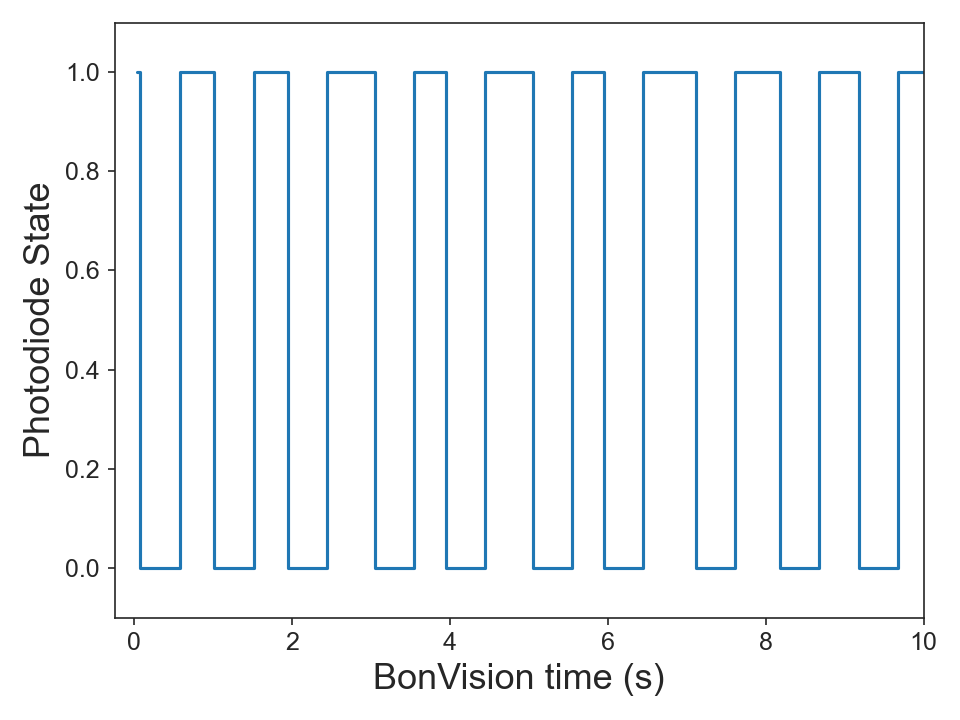

In [161]:
fig,ax=plt.subplots()

ax.tick_params(axis='x',which='major',reset=True,top=False,labelsize=12)
ax.tick_params(axis='y',which='major',reset=True,right=False,labelsize=12)

ax.plot(stim_df['Timestamp'],stim_df['photodiode_state'])

ax.set_xlim(-0.25,10)
ax.set_xlabel('BonVision time (s)')
ax.set_ylabel('Photodiode State')
ax.set_ylim(-0.1,1.1)
fig.tight_layout()
filen = '2026-03-30_bv_photodiode'
save_figure(fig,os.path.join(savepath,filen),formats=['.png','.pdf'],dpi=300)

In [153]:
fig,ax=plt.subplots()

ax.tick_params(axis='x',which='major',reset=True,top=False,labelsize=12)
ax.tick_params(axis='y',which='major',reset=True,right=False,labelsize=12)

ax.plot(stim_df['Timestamp'],stim_df['photodiode_state'])

ax.set_xlim(-0.25,10)
ax.set_xlabel('BonVision time (s)')
ax.set_ylabel('Photodiode State')
ax.set_ylim(-0.1,1.1)
fig.tight_layout()

,AnalogInput0
Time,
3.106958e+06,9
3.106958e+06,10
3.106958e+06,11
3.106958e+06,13
3.106958e+06,9
...,...
3.108763e+06,8
3.108763e+06,8
3.108763e+06,9
